# Workstream 1: Market sizing
**Client question:** is the US depression market big enough to justify a launch?

**This notebook answers three things**
1. How many adults have depression, nationally, by state and by county?
2. How much does Medicare spend on depression drugs, and how much of that is brands vs generics?
3. What is the *whole* US market likely worth, all payers, once we fill Medicare's gap with MEPS?

**Key analytical choices**
| # | Question | Approach |
|---|---|---|
| 1 | Which drugs | Two buckets: *core* antidepressants + *adjunct* antipsychotics (scaled by their depression share). Mostly-other-use drugs kept as a sensitivity view. Lists live in `scripts/drug_classes.py`. |
| 2 | Which rate | Crude rate to count patients; age-adjusted to compare counties |
| 3 | Dollars | Medicare as measured + national estimate scaled with MEPS payer shares (triangulation) |

In [1]:
import sys, zipfile
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, "../scripts")
from drug_classes import classify, is_brand

RAW, OUT, FIG = "../data/raw/", "../data/processed/", "../outputs/"
pd.set_option("display.float_format", "{:,.1f}".format)

# MEPS survey year: change this one line when a new MEPS year is released
MEPS_YEAR = 2024
YY = str(MEPS_YEAR)[-2:]

def read_meps(kind, columns=None):
    """Read a MEPS Stata file (rx / conditions / clnk) for MEPS_YEAR, whatever the .dta file inside the zip is called."""
    z = zipfile.ZipFile(RAW + f"meps_{MEPS_YEAR}_{ {'rx': 'prescribed_medicines', 'conditions': 'conditions', 'clnk': 'clnk'}[kind] }_dta.zip")
    dta = [n for n in z.namelist() if n.lower().endswith(".dta") and not n.startswith("__MACOSX")][0]   # skip macOS zip metadata
    return pd.read_stata(z.open(dta), convert_categoricals=False, columns=columns)

## Step 1: Patients (CDC PLACES, 2023 survey, 2025 release)
Measure `DEPRESSION` = share of adults ever told by a doctor they have depression. It covers **all adults, all insurance types**.

- `CrdPrv` = crude rate, used to **count** patients
- `AgeAdjPrv` = age-adjusted rate, used to **compare** counties

**Data note:** Kentucky and Pennsylvania have no county estimates in this release (their 2023 survey data didn't meet CDC's standards). The national figure comes from CDC's own US-level estimate, which includes them. For county and state views, they are filled from the previous release (2022 survey) after a year-to-year stability check, and labelled in a `source` column.

In [2]:
places = pd.read_csv(RAW + "cdc_places_county_2025.csv", dtype={"locationid": str})
dep = places[places.measureid == "DEPRESSION"]

# National estimate (CDC's own US row)
us = dep[dep.stateabbr == "US"].set_index("datavaluetypeid")
us_rate, us_adults = us.loc["CrdPrv", "data_value"], us.loc["CrdPrv", "totalpop18plus"]
us_patients = us_rate / 100 * us_adults
print(f"US: {us_rate:.1f}% of {us_adults/1e6:,.0f}M adults = {us_patients/1e6:,.1f}M adults ever diagnosed with depression")

# County table: one row per county, both rates side by side
county = (dep[dep.stateabbr != "US"]
          .pivot_table(index=["locationid", "stateabbr", "locationname", "totalpop18plus"],
                       columns="datavaluetypeid", values="data_value")
          .reset_index()
          .rename(columns={"locationid": "fips", "locationname": "county", "totalpop18plus": "adults",
                           "CrdPrv": "rate_crude", "AgeAdjPrv": "rate_ageadj"}))
county["patients"] = county.rate_crude / 100 * county.adults
print(f"{len(county):,} counties in the 2025 release")

top10 = county.sort_values("patients", ascending=False).head(10)
top10.style.format({"adults": "{:,.0f}", "patients": "{:,.0f}", "rate_crude": "{:.1f}", "rate_ageadj": "{:.1f}"})

US: 20.2% of 262M adults = 52.9M adults ever diagnosed with depression
2,956 counties in the 2025 release


datavaluetypeid,fips,stateabbr,county,adults,rate_ageadj,rate_crude,patients
205,06037,CA,Los Angeles,"7,710,575",19.3,19.0,"1,465,009"
612,17031,IL,Cook,"4,031,580",19.0,18.7,"753,905"
2438,48201,TX,Harris,"3,595,915",19.5,19.7,"708,395"
104,04013,AZ,Maricopa,"3,572,375",18.9,18.6,"664,462"
223,06073,CA,San Diego,"2,594,848",21.2,21.1,"547,513"
216,06059,CA,Orange,"2,489,875",19.4,19.0,"473,076"
2783,53033,WA,King,"1,836,529",23.4,23.5,"431,584"
219,06065,CA,Riverside,"1,899,181",22.0,21.7,"412,122"
2394,48113,TX,Dallas,"1,960,720",19.1,19.3,"378,419"
2556,48439,TX,Tarrant,"1,635,353",22.6,22.7,"371,225"


In [3]:
# Data profile: what is in the CDC PLACES file?
print(f"Rows: {len(places):,} | measures: {sorted(places.measureid.unique())} | rate types: {sorted(places.datavaluetypeid.unique())}")
print(f"Survey year: {sorted(places.year.unique())} | depression rows: {len(dep):,} | counties: {dep[dep.stateabbr != 'US'].locationid.nunique():,} "
      f"| states + DC: {dep[dep.stateabbr != 'US'].stateabbr.nunique()} | national row present: {'US' in set(dep.stateabbr)}")
print(f"Missing depression values: {dep.data_value.isna().sum()}")

Rows: 23,664 | measures: ['ACCESS2', 'CHECKUP', 'DEPRESSION', 'MHLTH'] | rate types: ['AgeAdjPrv', 'CrdPrv']
Survey year: [np.int64(2023)] | depression rows: 5,916 | counties: 2,957 | states + DC: 49 | national row present: True
Missing depression values: 2


In [4]:
# Fill Kentucky and Pennsylvania from the previous PLACES release (2022 survey), after checking it is safe to do so
p24 = pd.read_csv(RAW + "cdc_places_county_2024.csv", dtype={"locationid": str})
p24 = (p24[(p24.measureid == "DEPRESSION") & (p24.stateabbr != "US")]
       .pivot_table(index=["locationid", "stateabbr", "locationname", "totalpop18plus"],
                    columns="datavaluetypeid", values="data_value")
       .reset_index()
       .rename(columns={"locationid": "fips", "locationname": "county", "totalpop18plus": "adults",
                        "CrdPrv": "rate_crude", "AgeAdjPrv": "rate_ageadj"}))

# 1. Proper missing-states check: compare against all 50 states + DC
ALL_STATES = set("AL AK AZ AR CA CO CT DE DC FL GA HI ID IL IN IA KS KY LA ME MD MA MI MN MS MO MT NE NV NH NJ NM NY "
                 "NC ND OH OK OR PA RI SC SD TN TX UT VT VA WA WV WI WY".split())
missing = sorted(ALL_STATES - set(county.stateabbr))
print("States missing from the 2025 release:", missing)

# 2. Stability check: for counties in BOTH releases, how much did the rate move between the 2022 and 2023 surveys?
both = county.merge(p24[["fips", "rate_crude"]], on="fips", suffixes=("_2025rel", "_2024rel"))
diff = both.rate_crude_2025rel - both.rate_crude_2024rel
print(f"Counties in both releases: {len(both):,} | correlation of rates: {both.rate_crude_2025rel.corr(both.rate_crude_2024rel):.2f} "
      f"| median change: {diff.median():+.1f} pts | 90% of counties within ±{diff.abs().quantile(0.9):.1f} pts")

# 3. Fill the missing states from the 2024 release and flag them
fill = p24[p24.stateabbr.isin(missing)].copy()
fill["patients"] = fill.rate_crude / 100 * fill.adults
fill["source"] = "PLACES 2024 release (2022 survey)"
county["source"] = "PLACES 2025 release (2023 survey)"
county = pd.concat([county, fill], ignore_index=True)
print(f"Added {len(fill):,} counties from {missing}; county table now has {len(county):,} counties, "
      f"{county.stateabbr.nunique()} jurisdictions (50 states + DC)")

States missing from the 2025 release: ['KY', 'PA']
Counties in both releases: 2,956 | correlation of rates: 0.89 | median change: -0.2 pts | 90% of counties within ±2.5 pts
Added 187 counties from ['KY', 'PA']; county table now has 3,143 counties, 51 jurisdictions (50 states + DC)


In [5]:
# By state: where are the most patients (size) and the highest rates (intensity)?
state = (county.groupby("stateabbr")
         .agg(adults=("adults", "sum"), patients=("patients", "sum"))
         .assign(rate=lambda x: x.patients / x.adults * 100)
         .sort_values("patients", ascending=False))
state["patients_M"] = state.patients / 1e6
print("Most patients:"); display(state.head(8)[["patients_M", "rate"]])
print("Highest rates (states with 1M+ adults):"); display(state[state.adults > 1e6].sort_values("rate", ascending=False).head(8)[["patients_M", "rate"]])

Most patients:


,patients_M,rate
stateabbr,,
CA,6.1,20.1
TX,4.9,21.2
FL,3.1,17.1
NY,2.7,17.5
PA,2.4,23.0
OH,2.3,25.4
NC,2.1,24.2
MI,2.0,25.7


Highest rates (states with 1M+ adults):


,patients_M,rate
stateabbr,,
WV,0.4,30.4
TN,1.6,28.4
UT,0.7,27.3
OR,0.9,27.1
ME,0.3,26.9
KY,0.9,26.7
LA,0.9,26.6
MI,2.0,25.7


## Step 2: Medicare Part D spending, 2024 (national)
`Tot_Drug_Cst` = total paid for the drug by plans + patients, **before manufacturer rebates** (list-price view).

Note: never add up `Tot_Benes` across drugs. One person on two drugs would be counted twice.

In [6]:
geo = pd.read_csv(RAW + "cms_partd_geo_drug.csv", low_memory=False)
nat = geo[geo.Prscrbr_Geo_Lvl == "National"].copy()
nat["bucket"] = [classify(g, b) for g, b in zip(nat.Gnrc_Name, nat.Brnd_Name)]
nat["brand"] = [is_brand(b, g) for b, g in zip(nat.Brnd_Name, nat.Gnrc_Name)]
nat = nat[nat.bucket != "not_depression"]

mcare = nat.groupby("bucket")[["Tot_Clms", "Tot_Drug_Cst"]].sum()
mcare["cost_per_claim"] = mcare.Tot_Drug_Cst / mcare.Tot_Clms
display((mcare.assign(claims_M=mcare.Tot_Clms/1e6, spend_B=mcare.Tot_Drug_Cst/1e9))[["claims_M", "spend_B", "cost_per_claim"]])

,claims_M,spend_B,cost_per_claim
bucket,,,
adjunct,15.1,2.5,163.5
core,87.0,2.3,26.7
other_use,29.3,1.8,62.0


In [7]:
# Data profile: what is in the Medicare Part D file?
print(f"Rows: {len(geo):,} | levels: {geo.Prscrbr_Geo_Lvl.value_counts().to_dict()} | national drug rows: {len(geo[geo.Prscrbr_Geo_Lvl == 'National']):,}")
prof = nat.assign(product_type=nat.brand.map({True: "Brand", False: "Generic"})).groupby(["bucket", "product_type"]).agg(
    products=("Brnd_Name", "nunique"), fills_M=("Tot_Clms", lambda s: s.sum() / 1e6), spend_M=("Tot_Drug_Cst", lambda s: s.sum() / 1e6))
display(prof.round(1))

Rows: 117,661 | levels: {'State': 114029, 'National': 3632} | national drug rows: 3,632


products  fills_M  spend_M
bucket    product_type                            
adjunct   Brand                7      1.4  2,019.8
          Generic              5     13.7    448.1
core      Brand               26      1.0    857.8
          Generic             30     86.0  1,463.3
other_use Brand               13      0.6  1,393.4
          Generic              9     28.7    421.2

In [8]:
# Brands vs generics inside each bucket: share of prescriptions vs share of money
for b in ["core", "adjunct"]:
    x = nat[nat.bucket == b].groupby("brand")[["Tot_Clms", "Tot_Drug_Cst"]].sum()
    x = x / x.sum() * 100
    x.index = x.index.map({True: "brand", False: "generic"})
    print(f"\n{b.upper()}: % of claims vs % of spend"); display(x.rename(columns={"Tot_Clms": "% claims", "Tot_Drug_Cst": "% spend"}))

# Top 15 depression drugs by Medicare spend, brands and generics together
generic_ingredients = set(nat.loc[~nat.brand, "Gnrc_Name"].str.lower())

top = (nat[nat.bucket.isin(["core", "adjunct"])]
       .groupby(["Brnd_Name", "Gnrc_Name", "bucket", "brand"], as_index=False)[["Tot_Clms", "Tot_Drug_Cst"]].sum()
       .assign(product_type=lambda x: x.brand.map({True: "Brand", False: "Generic"}),
               generic_available=lambda x: x.Gnrc_Name.str.lower().isin(generic_ingredients).map({True: "Yes", False: "No"}),
               claims_M=lambda x: x.Tot_Clms / 1e6,
               spend_M=lambda x: x.Tot_Drug_Cst / 1e6,
               cost_per_claim=lambda x: x.Tot_Drug_Cst / x.Tot_Clms)
       .sort_values("Tot_Drug_Cst", ascending=False)
       .head(15)
       .rename(columns={"Brnd_Name": "product", "Gnrc_Name": "ingredient"}))

top[["product", "ingredient", "product_type", "generic_available", "bucket",
     "claims_M", "spend_M", "cost_per_claim"]].style.format(
    {"claims_M": "{:,.1f}", "spend_M": "${:,.0f}M", "cost_per_claim": "${:,.0f}"}).hide(axis="index")


CORE: % of claims vs % of spend


,% claims,% spend
brand,,
generic,98.9,63.0
brand,1.1,37.0



ADJUNCT: % of claims vs % of spend


,% claims,% spend
brand,,
generic,90.8,18.2
brand,9.2,81.8


product,ingredient,product_type,generic_available,bucket,claims_M,spend_M,cost_per_claim
Vraylar,Cariprazine Hcl,Brand,No,adjunct,0.8,"$1,135M","$1,481"
Rexulti,Brexpiprazole,Brand,No,adjunct,0.6,$861M,"$1,439"
Trintellix,Vortioxetine Hydrobromide,Brand,No,core,0.6,$392M,$643
Duloxetine Hcl,Duloxetine Hcl,Generic,Yes,core,13.1,$309M,$24
Aripiprazole,Aripiprazole,Generic,Yes,adjunct,3.8,$245M,$64
Bupropion Xl,Bupropion Hcl,Generic,Yes,core,6.8,$169M,$25
Quetiapine Fumarate,Quetiapine Fumarate,Generic,Yes,adjunct,9.3,$160M,$17
Mirtazapine,Mirtazapine,Generic,Yes,core,8.3,$158M,$19
Sertraline Hcl,Sertraline Hcl,Generic,Yes,core,16.1,$147M,$9
Escitalopram Oxalate,Escitalopram Oxalate,Generic,Yes,core,12.7,$141M,$11


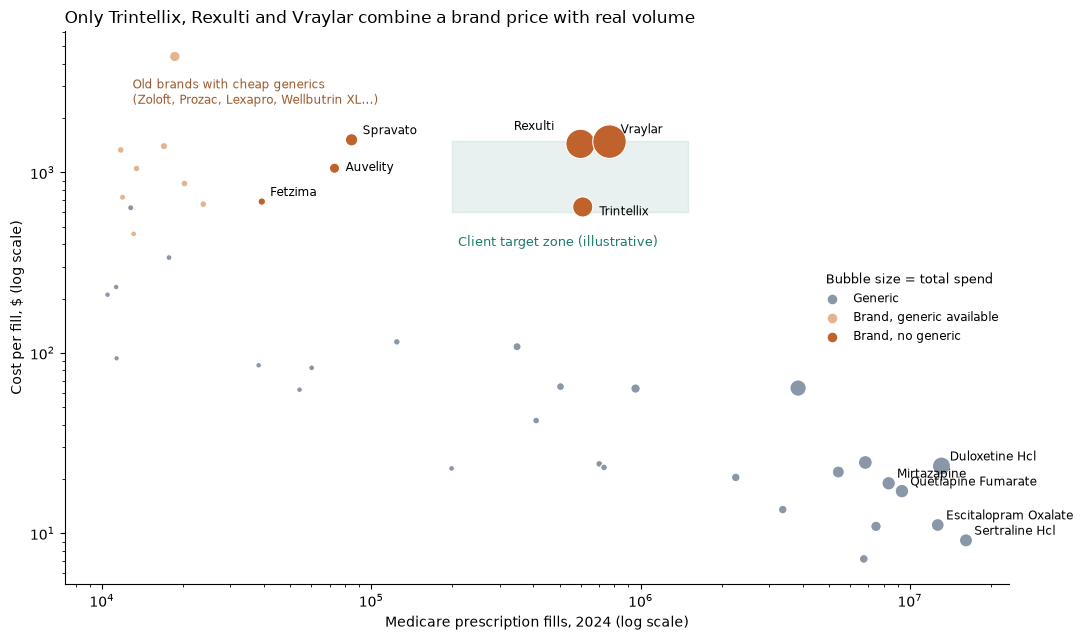

In [9]:
# Price-volume map: every core/adjunct product with at least 10,000 Medicare fills in 2024
pv = (nat[nat.bucket.isin(["core", "adjunct"])]
      .groupby(["Brnd_Name", "Gnrc_Name", "brand"], as_index=False)[["Tot_Clms", "Tot_Drug_Cst"]].sum())
pv = pv[pv.Tot_Clms >= 10_000].assign(
    cost_per_claim=lambda x: x.Tot_Drug_Cst / x.Tot_Clms,
    group=lambda x: ["Generic" if not b else ("Brand, generic available" if g.lower() in generic_ingredients
                     else "Brand, no generic") for b, g in zip(x.brand, x.Gnrc_Name)])

fig, ax = plt.subplots(figsize=(11, 6.5))
styles = {"Generic": "#8A97A8", "Brand, generic available": "#E3B48F", "Brand, no generic": "#C0622B"}
for grp, color in styles.items():
    d = pv[pv.group == grp]
    ax.scatter(d.Tot_Clms, d.cost_per_claim, s=d.Tot_Drug_Cst / 2e6 + 15, color=color,
               edgecolor="white", linewidth=0.8, label=grp, zorder=3)

# Client target zone (illustrative): brand-level price with Trintellix/Vraylar-level reach
ax.fill_between([2e5, 1.5e6], 600, 1500, color="#1F7A70", alpha=0.10, zorder=1)
ax.text(2.1e5, 450, "Client target zone (illustrative)", color="#1F7A70", fontsize=9, va="top")

offsets = {"Vraylar": (8, 6), "Rexulti": (-48, 10), "Spravato": (8, 4), "Auvelity": (8, -2), "Trintellix": (12, -6)}
to_label = pd.concat([pv[pv.group == "Brand, no generic"], pv[pv.group == "Generic"].nlargest(5, "Tot_Clms")])
for _, r in to_label.iterrows():
    ax.annotate(r.Brnd_Name, (r.Tot_Clms, r.cost_per_claim), xytext=offsets.get(r.Brnd_Name, (6, 4)),
                textcoords="offset points", fontsize=8.5)
ax.annotate("Old brands with cheap generics\n(Zoloft, Prozac, Lexapro, Wellbutrin XL...)", (1.3e4, 2.4e3),
            fontsize=8.5, color="#9A5A2E")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Medicare prescription fills, 2024 (log scale)")
ax.set_ylabel("Cost per fill, $ (log scale)")
ax.set_title("Only Trintellix, Rexulti and Vraylar combine a brand price with real volume", loc="left", fontsize=12)
leg = ax.legend(title="Bubble size = total spend", frameon=False, loc="center right", fontsize=8.5, title_fontsize=9)
for h in leg.legend_handles:
    h.set_sizes([60])
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG + "ws1_price_volume_map.png", dpi=200); plt.show()

## Step 3: MEPS (all payers): who pays, and what are the drugs used for?
MEPS records every prescription fill in a national household survey, with **who paid** and **which condition** it treated.
Each person has a survey weight (`PERWT`, e.g. `PERWT24F` in the 2024 file) so the sample represents the whole US.

The survey year is set once in the setup cell (`MEPS_YEAR`). Year-specific column names (e.g. `RXMR24X`) are renamed to generic ones (`RXMR`) on load, so the rest of the notebook works for any year.

In [10]:
# Load MEPS prescribed medicines for MEPS_YEAR and give the year-specific columns generic names
year_cols = {f"RXSF{YY}X": "RXSF", f"RXMR{YY}X": "RXMR", f"RXMD{YY}X": "RXMD", f"RXPV{YY}X": "RXPV",
             f"RXXP{YY}X": "RXXP", f"PERWT{YY}F": "PERWT"}
rx = read_meps("rx", columns=["DUPERSID", "LINKIDX", "RXNAME", "RXDRGNAM"] + list(year_cols)).rename(columns=year_cols)
print(f"MEPS {MEPS_YEAR}: {len(rx):,} prescription fills in the survey")
rx["bucket"] = [classify(g, n) for g, n in zip(rx.RXDRGNAM.astype(str), rx.RXNAME.astype(str))]
rx = rx[rx.bucket.isin(["core", "adjunct"])].copy()

MEPS 2024: 204,550 prescription fills in the survey


**3a. What is in the sample?** Check the mix of buckets and brands before trusting any MEPS share. MEPS shortens drug names to 12 characters, so brands are recognised using the Medicare brand list.

In [11]:
# What is actually in the MEPS sample? (check this before trusting any MEPS share)
from drug_classes import brand_names_from_cms, meps_is_brand

cms_brands = brand_names_from_cms(geo)                      # brand names from the Medicare file
rx["product_type"] = ["Brand" if meps_is_brand(n, cms_brands) else "Generic" for n in rx.RXNAME]
rx["wspend"] = rx.RXXP * rx.PERWT                    # survey-weighted dollars

composition = (rx.groupby(["bucket", "product_type"])
                 .agg(records=("RXNAME", "size"), national_spend_M=("wspend", lambda s: s.sum() / 1e6)))
display(composition.style.format({"records": "{:,.0f}", "national_spend_M": "${:,.0f}M"}))
print("Brand records by name:", rx[rx.product_type == "Brand"].RXNAME.value_counts().to_dict())

# How often do patients pay the whole bill themselves? (core antidepressants)
c = rx[(rx.bucket == "core") & (rx.RXXP > 0)]
fully_oop = (c.RXSF >= c.RXXP)
print(f"Core fills paid entirely out of pocket: {(fully_oop * c.PERWT).sum() / c.PERWT.sum():.0%} (weighted); "
      f"median fill ${c.RXXP.median():,.0f}")

Brand records by name: {'ZOLOFT': 33, 'WELLBUTRIN': 32, 'ABILIFY': 14, 'WELLBUTRIN XL': 4}
Core fills paid entirely out of pocket: 45% (weighted); median fill $12


**3b. Payer shares:** what share of spending does each payer cover? Used to scale Medicare and Medicaid up to the national market.

In [12]:
payers = {"RXMR": "Medicare", "RXMD": "Medicaid", "RXPV": "Private", "RXSF": "Out of pocket", "RXXP": "Total"}
w = rx[list(payers)].mul(rx.PERWT, axis=0).assign(bucket=rx.bucket).groupby("bucket").sum().rename(columns=payers)
shares = w.div(w.Total, axis=0) * 100
shares["Other"] = 100 - shares[["Medicare", "Medicaid", "Private", "Out of pocket"]].sum(axis=1)
print(f"Share of spending by payer (%), MEPS {MEPS_YEAR}:"); display(shares.drop(columns="Total"))
print("Unweighted fills in sample:", rx.bucket.value_counts().to_dict())
print("MEPS national spend, $B:", (w.Total / 1e9).round(2).to_dict())

Share of spending by payer (%), MEPS 2024:


,Medicare,Medicaid,Private,Out of pocket,Other
bucket,,,,,
adjunct,70.5,6.2,13.8,8.4,1.1
core,18.5,13.7,31.0,31.3,5.6


Unweighted fills in sample: {'core': 13171, 'adjunct': 1110}
MEPS national spend, $B: {'adjunct': 1.19, 'core': 5.81}


**3c. Depression share:** for each fill, follow the link to the condition it was prescribed for.
Depression = ICD-10 `F32` / `F33`. Bipolar = `F31`. Schizophrenia = `F20`, `F25`, `F29`. Fills with no linked condition are left out.

**Counted by prescriptions, not dollars.** Each fill counts once (× its survey weight). Weighting by dollars lets a few very expensive fills from two or three survey respondents dominate: the dollar-weighted shares swung sharply between MEPS 2023 and 2024, while the prescription-count shares stayed stable (core ~48–49%, add-on ~31–32%). Payer shares (3b) stay in dollars, because they are used to scale dollars.

In [13]:
clnk = read_meps("clnk")
cond = read_meps("conditions", columns=["CONDIDX", "ICD10CDX"])
link = clnk[clnk.EVENTYPE == 8].merge(cond, on="CONDIDX")          # EVENTYPE 8 = prescribed medicine
link["depression"] = link.ICD10CDX.isin(["F32", "F33"])
link["bipolar"] = link.ICD10CDX.eq("F31")
link["schizophrenia"] = link.ICD10CDX.isin(["F20", "F25", "F29"])
link["anxiety"] = link.ICD10CDX.eq("F41")
flags = link.groupby("EVNTIDX")[["depression", "bipolar", "schizophrenia", "anxiety"]].max()

m = rx.merge(flags, left_on="LINKIDX", right_index=True, how="inner")   # fills with a linked condition
m["ingredient"] = m.RXDRGNAM.str.split().str[0]
m["wspend"] = m.RXXP * m.PERWT

def share(g, by="count"):
    """% of a group's fills linked to each condition. by="count": each fill counts once x survey weight (used).
    by="dollars": weighted by spend (shown for comparison only; unstable because of a few very expensive fills)."""
    w = g.PERWT if by == "count" else g.wspend
    return pd.Series({c: (w * g[c]).sum() / w.sum() * 100 for c in ["depression", "bipolar", "schizophrenia", "anxiety"]}
                     | {"fills": len(g)})
print(f"% of prescriptions linked to each condition (MEPS {MEPS_YEAR}, counted by prescriptions):")
display(m.groupby("bucket").apply(share))
display(m[m.bucket == "adjunct"].groupby("ingredient").apply(share))

print("For comparison only, weighted by dollars (not used):")
display(m.groupby("bucket").apply(lambda g: share(g, by="dollars"))[["depression", "anxiety"]])

# Check the assumption behind applying a prescription share to dollars: do depression fills cost about the same as others?
cost_check = (m.assign(condition=m.depression.map({True: "depression", False: "other"}))
                .groupby(["bucket", "condition"])
                .apply(lambda g: pd.Series({"median $ per fill": g.RXXP.median(),
                                            "weighted mean $ per fill": (g.RXXP * g.PERWT).sum() / g.PERWT.sum(),
                                            "fills": len(g)})))
display(cost_check.round(1))

% of prescriptions linked to each condition (MEPS 2024, counted by prescriptions):


/var/folders/pj/mlz69msj4tv3bsptvg3xzzfw0000gn/T/ipykernel_7001/3922129588.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(m.groupby("bucket").apply(share))


,depression,bipolar,schizophrenia,anxiety,fills
bucket,,,,,
adjunct,31.6,20.0,0.0,18.4,"1,042.0"
core,48.2,1.1,0.0,42.8,"12,724.0"


/var/folders/pj/mlz69msj4tv3bsptvg3xzzfw0000gn/T/ipykernel_7001/3922129588.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(m[m.bucket == "adjunct"].groupby("ingredient").apply(share))


,depression,bipolar,schizophrenia,anxiety,fills
ingredient,,,,,
ARIPIPRAZOLE,48.3,25.2,0.0,16.8,480.0
QUETIAPINE,15.7,15.1,0.0,19.9,562.0


For comparison only, weighted by dollars (not used):


/var/folders/pj/mlz69msj4tv3bsptvg3xzzfw0000gn/T/ipykernel_7001/3922129588.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(m.groupby("bucket").apply(lambda g: share(g, by="dollars"))[["depression", "anxiety"]])


,depression,anxiety
bucket,,
adjunct,27.5,15.0
core,56.2,31.9


/var/folders/pj/mlz69msj4tv3bsptvg3xzzfw0000gn/T/ipykernel_7001/3922129588.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({"median $ per fill": g.RXXP.median(),


median $ per fill  weighted mean $ per fill   fills
bucket  condition                                                      
adjunct depression               13.0                      63.9   323.0
        other                    13.0                      77.8   719.0
core    depression               12.6                      31.5 6,310.0
        other                    11.2                      22.9 6,414.0

## Step 4: Triangulate the national market
CMS has exact dollars, but only for Medicare and Medicaid; MEPS covers every payer but as a survey. So we combine them.

**Core antidepressants:** three estimates of national spend
1. **Medicare ÷ Medicare's share** (CMS 2024 ÷ MEPS share)
2. **Medicaid ÷ Medicaid's share** (CMS 2024 ÷ MEPS share)
3. **MEPS direct** (survey total; surveys undercount, so this is the low end)

**Add-on antipsychotics:** MEPS has no branded antipsychotic records, so its shares cannot scale brand-heavy CMS dollars. We use measured Medicare + Medicaid spend as a floor.

Both buckets are then scaled by the share of their spending linked to depression (Step 3c).

In [14]:
mcd = pd.read_csv(RAW + "cms_medicaid_spending_by_drug.csv", low_memory=False)
mcd = mcd[mcd.Mftr_Name == "Overall"].copy()        # 'Overall' rows = all manufacturers; other rows would double count
mcd["bucket"] = [classify(g, b) for g, b in zip(mcd.Gnrc_Name, mcd.Brnd_Name)]
medicaid_2024 = mcd.groupby("bucket").Tot_Spndng_2024.sum()

tri = pd.DataFrame({
    "Medicare 2024 ($B)": mcare.Tot_Drug_Cst / 1e9,
    "Medicaid 2024 ($B)": medicaid_2024 / 1e9,
    "MEPS Medicare share %": shares.Medicare,
    "MEPS Medicaid share %": shares.Medicaid,
}).loc[["core", "adjunct"]]
tri["1. via Medicare ($B)"] = tri["Medicare 2024 ($B)"] / (tri["MEPS Medicare share %"] / 100)
tri["2. via Medicaid ($B)"] = tri["Medicaid 2024 ($B)"] / (tri["MEPS Medicaid share %"] / 100)
tri["3. MEPS direct ($B)"] = w.Total / 1e9
tri.round(2).T

bucket,core,adjunct
Medicare 2024 ($B),2.3,2.5
Medicaid 2024 ($B),1.2,2.1
MEPS Medicare share %,18.5,70.5
MEPS Medicaid share %,13.7,6.2
1. via Medicare ($B),12.6,3.5
2. via Medicaid ($B),9.0,34.0
3. MEPS direct ($B),5.8,1.2


In [15]:
# Depression-addressable market: scale BOTH buckets by the share of spending linked to depression (MEPS, Step 3c)
dep_core     = share(m[m.bucket == "core"])["depression"] / 100                                          # core row (count-based)
dep_adj_base = share(m[m.bucket == "adjunct"])["depression"] / 100                                       # adjunct row (count-based), low case
dep_adj_high = share(m[(m.bucket == "adjunct") & (m.ingredient == "ARIPIPRAZOLE")])["depression"] / 100  # aripiprazole row (count-based), high case

methods = ["1. via Medicare ($B)", "2. via Medicaid ($B)", "3. MEPS direct ($B)"]

# Core: MEPS has a large, generic-heavy sample -> all three scaling methods are usable
core = pd.DataFrame({"core, all uses ($B)": tri.loc["core", methods]})
core["core, depression share ($B)"] = core.iloc[:, 0] * dep_core

# Adjunct: MEPS has no Vraylar/Rexulti records, so MEPS-based scaling is not reliable.
# Use what is actually measured instead: Medicare + Medicaid spend (a floor; private and cash spend come on top)
adj_floor = tri.loc["adjunct", "Medicare 2024 ($B)"] + tri.loc["adjunct", "Medicaid 2024 ($B)"]

summary = pd.DataFrame({
    "low ($B)":  [core.iloc[:, 1].min(), adj_floor * dep_adj_base],
    "high ($B)": [core.iloc[:, 1].max(), adj_floor * dep_adj_high],
}, index=["Core antidepressants (depression share)", "Adjunct antipsychotics (depression share, Medicare + Medicaid floor)"])
summary.loc["Depression-addressable market"] = summary.sum()

print(f"Depression shares applied: core {dep_core:.0%} | adjunct {dep_adj_base:.0%} (bucket average) to {dep_adj_high:.0%} (aripiprazole)")
print(f"Adjunct measured spend, Medicare + Medicaid 2024: ${adj_floor:,.2f}B (list prices)")
display(core.round(2))
summary.round(2)

Depression shares applied: core 48% | adjunct 32% (bucket average) to 48% (aripiprazole)
Adjunct measured spend, Medicare + Medicaid 2024: $4.59B (list prices)


,"core, all uses ($B)","core, depression share ($B)"
1. via Medicare ($B),12.6,6.1
2. via Medicaid ($B),9.0,4.3
3. MEPS direct ($B),5.8,2.8


,low ($B),high ($B)
Core antidepressants (depression share),2.8,6.1
"Adjunct antipsychotics (depression share, Medicare + Medicaid floor)",1.4,2.2
Depression-addressable market,4.2,8.3


## Step 5: Save outputs
- `data/processed/county_depression.csv`: county table (incl. KY and PA, with a `source` column) for the targeting and supply-gap workstreams
- `data/processed/ws1_depression_market.csv`: low and high market estimate by bucket
- `outputs/ws1_market_build.png`, `outputs/ws1_price_volume_map.png`: charts for the deck

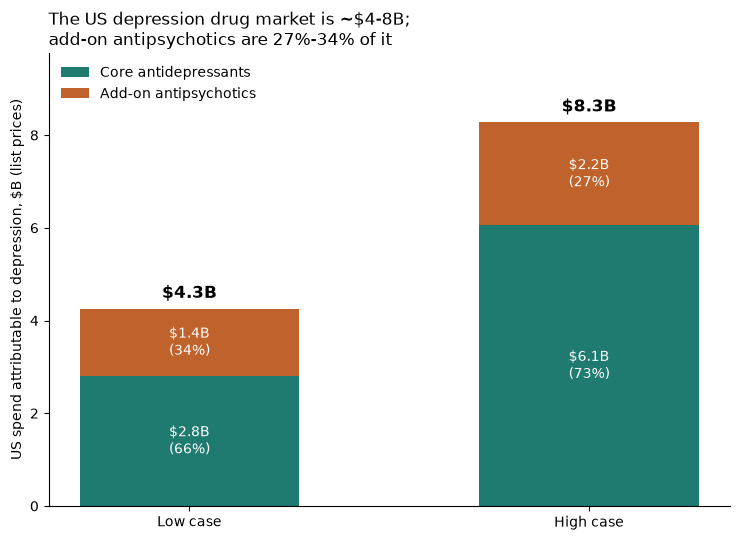

In [16]:
county.to_csv(OUT + "county_depression.csv", index=False)
summary.round(3).to_csv(OUT + "ws1_depression_market.csv")

# Stacked bars: total depression-addressable market, split into core and adjunct, for the low and high case
core_row = "Core antidepressants (depression share)"
adj_row = "Adjunct antipsychotics (depression share, Medicare + Medicaid floor)"
cases = ["low ($B)", "high ($B)"]
labels = ["Low case", "High case"]
core_vals = summary.loc[core_row, cases].values
adj_vals = summary.loc[adj_row, cases].values
totals = core_vals + adj_vals

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.bar(labels, core_vals, width=0.55, color="#1F7A70", label="Core antidepressants")
ax.bar(labels, adj_vals, width=0.55, bottom=core_vals, color="#C0622B", label="Add-on antipsychotics")
for i in range(2):
    ax.text(i, core_vals[i] / 2, f"${core_vals[i]:,.1f}B\n({core_vals[i] / totals[i]:.0%})",
            ha="center", va="center", color="white", fontsize=10)
    ax.text(i, core_vals[i] + adj_vals[i] / 2, f"${adj_vals[i]:,.1f}B\n({adj_vals[i] / totals[i]:.0%})",
            ha="center", va="center", color="white", fontsize=10)
    ax.text(i, totals[i] + 0.15, f"${totals[i]:,.1f}B", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylabel("US spend attributable to depression, $B (list prices)")
ax.set_title(f"The US depression drug market is ~${totals[0]:,.0f}-{totals[1]:,.0f}B;\n"
             f"add-on antipsychotics are {(adj_vals / totals).min():.0%}-{(adj_vals / totals).max():.0%} of it", loc="left", fontsize=12)
ax.set_ylim(0, totals.max() * 1.18)
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG + "ws1_market_build.png", dpi=200); plt.show()

## Step 6: Is the market growing, and what share can a new brand realistically win?
**6a. Growth.** CMS Spending by Drug follows the same products from 2020 to 2024 (Medicare Part D, list prices), so it shows real growth.
The change between our MEPS 2023 and 2024 estimates is *not* growth: it mostly reflects the change of survey year and method.
- *Spend growth / yr* = compound annual growth rate (CAGR), 2020 to 2024.
- Spend growth splits into **fills growth** (more prescriptions) and **cost per fill growth** (price and brand mix).

Products in core/adjunct buckets: 68 | by bucket: {'core': 56, 'adjunct': 12}
Products with no 2020 data (launched or first billed later): 5


,Spend 2020 ($B),Spend 2024 ($B),Spend growth / yr (%),Fills growth / yr (%),Cost per fill growth / yr (%),Brand share of spend 2024 (%)
bucket,,,,,,
core,2.5,2.3,-1.9,3.0,-4.8,37.0
adjunct,1.5,2.5,12.9,3.9,8.6,81.8


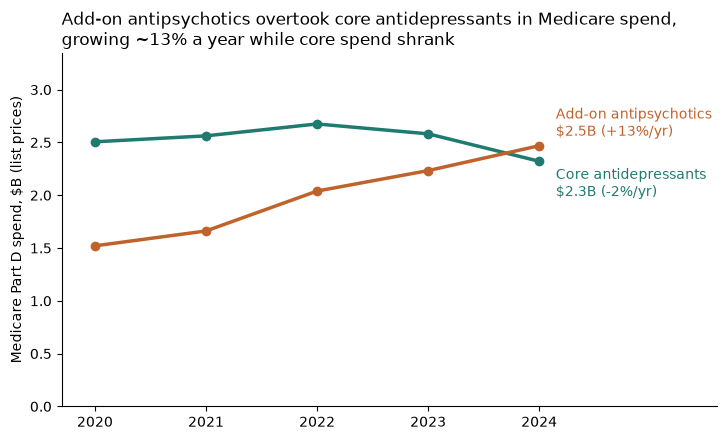

Add-on antipsychotics, brands vs generics:


,Fills 2020 (M),Fills 2024 (M),Fills growth / yr (%),Cost per fill 2020 ($),Cost per fill 2024 ($),Cost per fill growth / yr (%)
brand,,,,,,
Generics,12.2,13.7,2.9,50.9,32.7,-10.5
Brands,0.7,1.4,18.4,"1,267.8","1,452.0",3.5


Brand share of add-on fills: 5.5% (2020) -> 9.2% (2024). Growth comes mainly from patients shifting to brands (mix), not from higher prices per brand fill.


In [17]:
# Step 6a. Five-year Medicare trend (CMS Spending by Drug, 2020-2024): is the market growing, and which part?
spend = pd.read_csv(RAW + "cms_partd_spending_by_drug.csv", low_memory=False)
spend = spend[spend.Mftr_Name == "Overall"].copy()      # 'Overall' rows = all manufacturers combined; other rows would double count
spend["bucket"] = [classify(g, b) for g, b in zip(spend.Gnrc_Name, spend.Brnd_Name)]
spend["brand"] = [is_brand(b, g) for b, g in zip(spend.Brnd_Name, spend.Gnrc_Name)]
spend = spend[spend.bucket.isin(["core", "adjunct"])]
YEARS = list(range(2020, 2025))

# Data profile: what is in the file?
print(f"Products in core/adjunct buckets: {len(spend):,} | by bucket: {spend.bucket.value_counts().to_dict()}")
print(f"Products with no 2020 data (launched or first billed later): {spend.Tot_Spndng_2020.isna().sum()}")

def by_year(df, measure, scale):
    """Sum a CMS measure (e.g. Tot_Spndng) per bucket for each year; columns become plain years."""
    t = df.groupby("bucket")[[f"{measure}_{y}" for y in YEARS]].sum() / scale
    t.columns = YEARS
    return t

spend_t = by_year(spend, "Tot_Spndng", 1e9)            # $B
fills_t = by_year(spend, "Tot_Clms", 1e6)              # millions of fills
brand_t = by_year(spend[spend.brand], "Tot_Spndng", 1e9)

cagr = lambda t: ((t[2024] / t[2020]) ** (1 / 4) - 1) * 100   # compound annual growth rate, 2020 -> 2024
growth = pd.DataFrame({
    "Spend 2020 ($B)": spend_t[2020],
    "Spend 2024 ($B)": spend_t[2024],
    "Spend growth / yr (%)": cagr(spend_t),
    "Fills growth / yr (%)": cagr(fills_t),
    "Cost per fill growth / yr (%)": cagr(spend_t / fills_t),
    "Brand share of spend 2024 (%)": brand_t[2024] / spend_t[2024] * 100,
}).loc[["core", "adjunct"]]
display(growth.round(1))

# Chart: Medicare spend per year, core vs add-on
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for b, color, name, va in [("core", "#1F7A70", "Core antidepressants", "top"), ("adjunct", "#C0622B", "Add-on antipsychotics", "bottom")]:
    ax.plot(YEARS, spend_t.loc[b], marker="o", color=color, lw=2.5)
    nudge = 0.05 if va == "bottom" else -0.05          # move the two end labels apart so they don't overlap
    ax.text(2024.15, spend_t.loc[b, 2024] + nudge, f"{name}\n${spend_t.loc[b, 2024]:.1f}B ({growth.loc[b, 'Spend growth / yr (%)']:+.0f}%/yr)",
            color=color, va=va, fontsize=10)
ax.set_xticks(YEARS); ax.set_xlim(2019.7, 2025.6); ax.set_ylim(0, spend_t.values.max() * 1.25)
ax.set_ylabel("Medicare Part D spend, $B (list prices)")
ax.set_title("Add-on antipsychotics overtook core antidepressants in Medicare spend,\n"
             "growing ~13% a year while core spend shrank", loc="left", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG + "ws1_trend.png", dpi=200); plt.show()

# Where does the add-on growth come from? Split add-on fills and cost per fill into brands vs generics
adj_split = spend[spend.bucket == "adjunct"].groupby("brand")[["Tot_Clms_2020", "Tot_Clms_2024", "Tot_Spndng_2020", "Tot_Spndng_2024"]].sum()
split = pd.DataFrame({
    "Fills 2020 (M)": adj_split.Tot_Clms_2020 / 1e6,
    "Fills 2024 (M)": adj_split.Tot_Clms_2024 / 1e6,
    "Fills growth / yr (%)": ((adj_split.Tot_Clms_2024 / adj_split.Tot_Clms_2020) ** (1 / 4) - 1) * 100,
    "Cost per fill 2020 ($)": adj_split.Tot_Spndng_2020 / adj_split.Tot_Clms_2020,
    "Cost per fill 2024 ($)": adj_split.Tot_Spndng_2024 / adj_split.Tot_Clms_2024,
}).rename(index={True: "Brands", False: "Generics"})
split["Cost per fill growth / yr (%)"] = ((split["Cost per fill 2024 ($)"] / split["Cost per fill 2020 ($)"]) ** (1 / 4) - 1) * 100
print("Add-on antipsychotics, brands vs generics:"); display(split.round(1))
b20, b24 = (split.loc["Brands", f"Fills {y} (M)"] / split[f"Fills {y} (M)"].sum() * 100 for y in (2020, 2024))
print(f"Brand share of add-on fills: {b20:.1f}% (2020) -> {b24:.1f}% (2024). "
      "Growth comes mainly from patients shifting to brands (mix), not from higher prices per brand fill.")

**6b. Launch analogs.** How did comparable brands perform in Medicare?
- **Auvelity** (Axsome, launched Oct 2022) is the closest analog to the client: a novel non-serotonin pill from a mid-size biotech that launched on its own.
- **Trintellix** is the incumbent branded pill doctors switch to when the first antidepressant fails, the same job Auvelity competes for; it also shows what a branded switch option reaches at maturity. **Vraylar** and **Rexulti** show the add-on brands.
- Medicare is only part of each brand's sales, so Auvelity is cross-checked against Axsome's reported all-payer net sales, an **external input** (company results, not CMS data).

In [18]:
# Step 6b. Launch analogs: how fast did recent and leading brands build volume and spend in Medicare?
# External input (not in CMS data): Axsome's reported Auvelity net product sales, all payers, net of rebates.
# Source: Axsome FY2024 results press release, Feb 2025 (see docs/deck_notes.md)
AUVELITY_NET = {2023: 130.1, 2024: 291.4}     # $M
print("External input - Auvelity reported net sales ($M):", AUVELITY_NET)

ANALOGS = {"Auvelity": "Novel non-serotonin pill, mid-size biotech, launched Oct 2022",
           "Trintellix": "Branded switch option (core)",
           "Vraylar": "Leading add-on brand (MDD add-on approval Dec 2022)",
           "Rexulti": "Add-on brand (MDD add-on approval 2015)",
           "Spravato": "Nasal spray, mostly billed under Part B (Part D shown only)"}
an = spend[spend.Brnd_Name.isin(ANALOGS)].set_index("Brnd_Name")

an_spend = an[[f"Tot_Spndng_{y}" for y in YEARS]] / 1e6;  an_spend.columns = YEARS
an_fills = an[[f"Tot_Clms_{y}" for y in YEARS]] / 1e3;    an_fills.columns = YEARS
total_2024 = spend_t[2024].sum() * 1e3          # core + adjunct Medicare spend 2024, $M

analogs = pd.DataFrame({
    "Role": pd.Series(ANALOGS),
    "Fills 2024 (K)": an_fills[2024],
    "Spend 2024 ($M)": an_spend[2024],
    "Cost per fill 2024 ($)": an_spend[2024] / an_fills[2024] * 1e3,
    "Share of Medicare core+add-on spend 2024 (%)": an_spend[2024] / total_2024 * 100,
}).sort_values("Spend 2024 ($M)", ascending=False)
print("Medicare spend by year ($M):"); display(an_spend.round(0))
display(analogs.round(1))

# How much of Auvelity's business is Medicare? (Medicare list spend vs all-payer net sales)
medicare_part = an_spend.loc["Auvelity", 2024] / AUVELITY_NET[2024] * 100
print(f"Auvelity 2024: Medicare list spend ${an_spend.loc['Auvelity', 2024]:.0f}M vs ${AUVELITY_NET[2024]:.0f}M all-payer net sales "
      f"(~{medicare_part:.0f}%) -> mostly sold to commercially insured patients, so its Medicare share understates its real share")
# Auvelity competes with Trintellix for the same patients (branded pill to switch to when the first antidepressant fails)
print(f"Auvelity vs Trintellix, the incumbent branded switch pill: {an_fills.loc['Auvelity', 2024] / an_fills.loc['Trintellix', 2024]:.0%} "
      "of Trintellix's Medicare fills in Auvelity's second year")

External input - Auvelity reported net sales ($M): {2023: 130.1, 2024: 291.4}
Medicare spend by year ($M):


,2020,2021,2022,2023,2024
Brnd_Name,,,,,
Auvelity,NaN,NaN,1.0,34.0,77.0
Rexulti,358.0,403.0,490.0,630.0,861.0
Spravato,22.0,33.0,50.0,80.0,128.0
Trintellix,315.0,338.0,367.0,390.0,392.0
Vraylar,487.0,583.0,709.0,936.0,"1,136.0"


,Role,Fills 2024 (K),Spend 2024 ($M),Cost per fill 2024 ($),Share of Medicare core+add-on spend 2024 (%)
Vraylar,Leading add-on brand (MDD add-on approval Dec ...,767.0,"1,136.0","1,481.1",23.7
Rexulti,Add-on brand (MDD add-on approval 2015),598.5,861.4,"1,439.3",18.0
Trintellix,Branded switch option (core),610.0,392.5,643.4,8.2
Spravato,"Nasal spray, mostly billed under Part B (Part ...",84.5,128.1,"1,515.7",2.7
Auvelity,"Novel non-serotonin pill, mid-size biotech, la...",73.1,77.1,"1,054.7",1.6


Auvelity 2024: Medicare list spend $77M vs $291M all-payer net sales (~26%) -> mostly sold to commercially insured patients, so its Medicare share understates its real share
Auvelity vs Trintellix, the incumbent branded switch pill: 12% of Trintellix's Medicare fills in Auvelity's second year


**6c. Realistic revenue for the client.** Two stages, each from a real benchmark:
- **Year 1-2:** Auvelity's actual reported sales. Revenue is a fact, so it is the same in both columns; what varies is the **share** of our market it represents ($4.3B vs $8.3B).
- **Mature:** Trintellix's Medicare share applied to our market range.

Caveats: net sales are after rebates while our market is at list prices, so Auvelity's share is conservative; Medicare shares understate brands sold mostly to commercial patients (shown below the table), so the mature case is likely conservative too.

In [19]:
# Step 6c. What revenue is realistic for the client? Benchmarks for year 1-2 and for maturity
market = summary.loc["Depression-addressable market", ["low ($B)", "high ($B)"]] * 1e3   # $M, list prices
trintellix_share = analogs.loc["Trintellix", "Share of Medicare core+add-on spend 2024 (%)"]

rows = []
for yr, label in [(2023, "Year 1"), (2024, "Year 2")]:
    # Reported sales are a fact; the share it represents depends on which end of our market range is true
    rows.append({"Stage": label, "Benchmark": f"Auvelity {yr}, reported net sales",
                 "Share low (%)": AUVELITY_NET[yr] / market["high ($B)"] * 100,
                 "Share high (%)": AUVELITY_NET[yr] / market["low ($B)"] * 100,
                 "Revenue low ($M)": AUVELITY_NET[yr], "Revenue high ($M)": AUVELITY_NET[yr]})
# Maturity: Trintellix's Medicare share applied to our market range
rows.append({"Stage": "Mature", "Benchmark": "Trintellix, Medicare share x our market",
             "Share low (%)": trintellix_share, "Share high (%)": trintellix_share,
             "Revenue low ($M)": trintellix_share / 100 * market["low ($B)"],
             "Revenue high ($M)": trintellix_share / 100 * market["high ($B)"]})
outlook = pd.DataFrame(rows).set_index("Stage")
display(outlook.round(1))

auv_mcare_share = analogs.loc["Auvelity", "Share of Medicare core+add-on spend 2024 (%)"]
print(f"For comparison: Auvelity's Medicare-only share ({auv_mcare_share:.1f}%) would imply just "
      f"${auv_mcare_share / 100 * market['low ($B)']:.0f}-{auv_mcare_share / 100 * market['high ($B)']:.0f}M, "
      "well below its actual sales: Medicare data understates brands sold mostly to commercial patients.")

,Benchmark,Share low (%),Share high (%),Revenue low ($M),Revenue high ($M)
Stage,,,,,
Year 1,"Auvelity 2023, reported net sales",1.6,3.1,130.1,130.1
Year 2,"Auvelity 2024, reported net sales",3.5,6.9,291.4,291.4
Mature,"Trintellix, Medicare share x our market",8.2,8.2,348.4,677.8


For comparison: Auvelity's Medicare-only share (1.6%) would imply just $68-133M, well below its actual sales: Medicare data understates brands sold mostly to commercial patients.


## Step 7: Where first? Branded add-on use by state
A second-line branded pill wins first where doctors already prescribe branded add-ons **and** depression rates are high. All measures are calculated from Medicare Part D 2024 fills (`Tot_Clms`) and spend (`Tot_Drug_Cst`) per drug per state:
- *Branded add-on fills per 1,000 antidepressant fills* (**main measure**) = branded add-on fills ÷ core antidepressant fills × 1,000. Captures both how often doctors add an add-on to an antidepressant and how often they choose a brand; a rate, so fair across state sizes.
- *Brand share of add-on fills (%)* = branded add-on fills ÷ all add-on fills. Brand preference among add-ons only; diluted in states where generic quetiapine is used heavily for sleep, bipolar or schizophrenia.
- *Brand share of add-on spend (%)*: the same in dollars, openness to brand prices.
- *Branded add-on spend ($M)*: size of the prize.

Candidate first markets = above the median on **both** depression rate and the main measure (orange in the chart). Medicare only, and add-on drugs are also used for other conditions, so this ranks states rather than measuring their market in dollars.

CMS state-level rows: 59 geographies; dropped (not a state): ['Armed Forces Europe', 'Armed Forces Pacific', 'Foreign Country', 'Guam', 'Northern Mariana Islands', 'Puerto Rico', 'Unknown', 'Virgin Islands']
States in the table: 51
Medians: depression rate 22.7% | Branded add-on fills per 1,000 antidepressant fills 15.9
Candidate first markets (13 states above the median on both), sorted by Branded add-on fills per 1,000 antidepressant fills:


,"Branded add-on fills per 1,000 antidepressant fills",Brand share of add-on fills (%),Brand share of add-on spend (%),Branded add-on spend ($M),Depression rate (%),Patients (M)
stateabbr,,,,,,
LA,24.9,12.8,90.4,48.9,26.6,0.9
KY,24.4,14.7,87.3,62.9,26.7,0.9
MO,22.7,13.1,85.8,70.9,24.3,1.2
IN,22.5,16.7,85.6,73.9,25.1,1.3
TN,22.2,12.6,88.9,74.5,28.4,1.6
OK,22.0,14.5,88.2,32.2,25.5,0.8
ID,21.5,11.9,77.4,14.7,23.7,0.4
AL,21.2,12.0,85.5,45.0,23.3,0.9
MI,19.6,10.2,84.8,84.7,25.7,2.0


Ranks out of 51 (1 = highest) for the three 'scale and intensity' states:


,"Branded add-on fills per 1,000 antidepressant fills",Brand share of add-on fills (%),Brand share of add-on spend (%),Branded add-on spend ($M),Depression rate (%),Patients (M)
stateabbr,,,,,,
TN,7,7,2,9,2,11
MI,14,17,17,6,9,8
OH,15,8,19,4,11,6


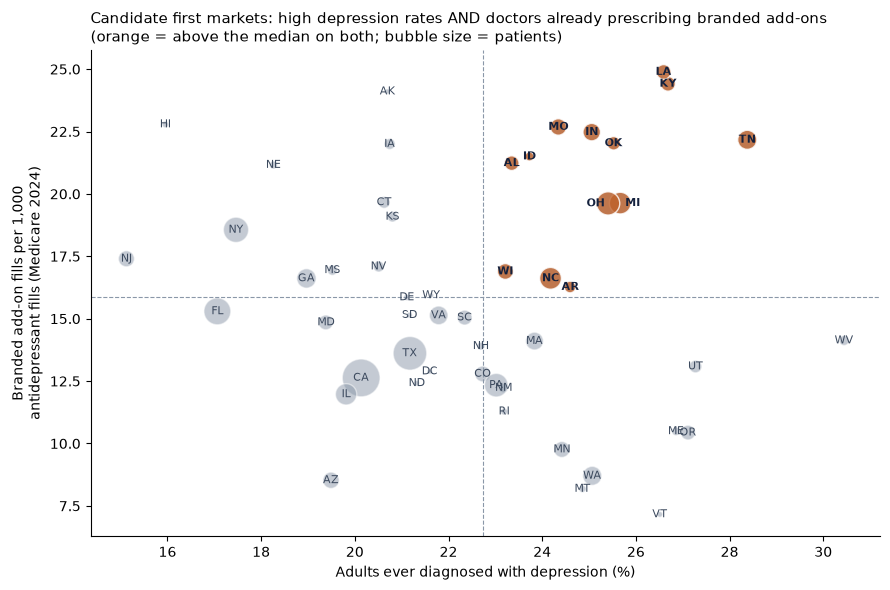

In [20]:
# Step 7. Where first? Branded add-on use by state (Medicare Part D 2024), next to depression rates (CDC PLACES)
st = geo[geo.Prscrbr_Geo_Lvl == "State"].copy()
st["bucket"] = [classify(g, b) for g, b in zip(st.Gnrc_Name, st.Brnd_Name)]
st["brand"] = [is_brand(b, g) for b, g in zip(st.Brnd_Name, st.Gnrc_Name)]
st = st[st.bucket.isin(["core", "adjunct"])]

# Map state names to abbreviations using the CDC file, which keeps the 50 states + DC (drops territories, 'Unknown', Armed Forces)
# (the 2024 release is added for Kentucky and Pennsylvania, which the 2025 release lacks)
names = (pd.concat([places[["statedesc", "stateabbr"]],
                    pd.read_csv(RAW + "cdc_places_county_2024.csv", usecols=["statedesc", "stateabbr"])])
         .drop_duplicates().query("stateabbr != 'US'").rename(columns={"statedesc": "Prscrbr_Geo_Desc"}))
print(f"CMS state-level rows: {st.Prscrbr_Geo_Desc.nunique()} geographies; dropped (not a state): "
      f"{sorted(set(st.Prscrbr_Geo_Desc.dropna()) - set(names.Prscrbr_Geo_Desc))}")
st = st.merge(names, on="Prscrbr_Geo_Desc")

g = lambda mask, col: st[mask].groupby("stateabbr")[col].sum()
adj, core_ = st.bucket == "adjunct", st.bucket == "core"
RANK_BY = "Branded add-on fills per 1,000 antidepressant fills"
states = pd.DataFrame({
    RANK_BY: g(adj & st.brand, "Tot_Clms") / g(core_, "Tot_Clms") * 1000,              # main measure: branded add-on use vs antidepressant base
    "Brand share of add-on fills (%)": g(adj & st.brand, "Tot_Clms") / g(adj, "Tot_Clms") * 100,   # among add-on fills only
    "Brand share of add-on spend (%)": g(adj & st.brand, "Tot_Drug_Cst") / g(adj, "Tot_Drug_Cst") * 100,
    "Branded add-on spend ($M)": g(adj & st.brand, "Tot_Drug_Cst") / 1e6,
}).join(state[["rate", "patients_M"]].rename(columns={"rate": "Depression rate (%)", "patients_M": "Patients (M)"}))
print(f"States in the table: {len(states)}")

# Candidate first markets = above the median on BOTH depression rate and branded add-on use (orange in the chart below)
x, y = states["Depression rate (%)"], states[RANK_BY]
print(f"Medians: depression rate {x.median():.1f}% | {RANK_BY} {y.median():.1f}")
hi = states[(x > x.median()) & (y > y.median())].index
print(f"Candidate first markets ({len(hi)} states above the median on both), sorted by {RANK_BY}:")
display(states.loc[hi].sort_values(RANK_BY, ascending=False).round(1))

ranks = states.rank(ascending=False).astype(int)
print(f"Ranks out of {len(states)} (1 = highest) for the three 'scale and intensity' states:")
display(ranks.loc[["TN", "MI", "OH"]])

# Quadrant chart: depression rate (x) vs branded add-on adoption (y); bubble size = patients
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, s=states["Patients (M)"] * 120, color="#8A97A8", alpha=0.5, edgecolor="white")
ax.axvline(x.median(), color="#8A97A8", lw=0.8, ls="--"); ax.axhline(y.median(), color="#8A97A8", lw=0.8, ls="--")
ax.scatter(x[hi], y[hi], s=states.loc[hi, "Patients (M)"] * 120, color="#C0622B", alpha=0.8, edgecolor="white")
NUDGE = {"OH": (-9, 0), "MI": (9, 0)}                 # two bubbles that sit on top of each other
for s_ in states.index:
    ax.annotate(s_, (x[s_], y[s_]), xytext=NUDGE.get(s_, (0, 0)), textcoords="offset points", fontsize=8, ha="center", va="center",
                color="#14213D" if s_ in hi else "#3C4A5E", fontweight="bold" if s_ in hi else "normal")
ax.set_xlabel("Adults ever diagnosed with depression (%)")
ax.set_ylabel("Branded add-on fills per 1,000\nantidepressant fills (Medicare 2024)")
ax.set_title("Candidate first markets: high depression rates AND doctors already prescribing branded add-ons\n"
             "(orange = above the median on both; bubble size = patients)", loc="left", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG + "ws1_where_first.png", dpi=200); plt.show()

states.round(2).to_csv(OUT + "ws1_state_launch_metrics.csv")

## Key takeaways
1. **Patients:** 52.9M US adults (20.2%) have been diagnosed with depression. Rates range from 15% (NJ) to 30% (WV); Tennessee, Michigan and Ohio combine high rates with large patient pools.
2. **Where the value is:** brands are 1-9% of Medicare depression-drug fills but 37-82% of the spend. Add-on antipsychotics are ~15% of fills but ~30% of the market's value, and brands take 82% of add-on spend. Only Trintellix, Vraylar and Rexulti combine a brand price ($640-1,480 per fill) with real volume.
3. **Market size:** the US depression drug market is ~$4.3-8.3B a year at list prices (core antidepressants $2.8-6.1B, add-ons $1.4-2.2B), after keeping only the share of prescriptions linked to depression (48% for core, 32-48% for add-ons).
4. **Growth:** Medicare add-on spend grew ~13% a year in 2020-24, driven by volume: branded add-on fills grew 18% a year while their price per fill rose only 3.5%. Core spend fell ~2% a year as generics got cheaper. Reported depression has also risen (10.5% to 18.3% of adults, 2015-25, Gallup).
5. **Realistic share:** Auvelity, a comparable mid-size launch, reached $130M in year 1 and $291M in year 2 (3.5-6.9% of the market). A mature share of 8-10%, between Trintellix (8%) and the add-on brands (18-24%), means ~$340-830M a year at list prices.
6. **Where first:** launch across six connected states, Tennessee, Kentucky, Indiana, Ohio, Michigan and Wisconsin: all above the median on depression rate and branded add-on use (17-24 branded add-on fills per 1,000 antidepressant fills vs a 16 median), 9.3M patients (~16% of the US). Michigan and Wisconsin also have less Caplyta presence (Workstream 2).

**So what for the client:** the US market is worth entering as a premium second-line pill. Compete for the branded add-on slot, price above Trintellix (~$640 per fill) and below Vraylar/Rexulti (~$1,450), justified by tolerability, and set the price against their negotiated Medicare prices (2027-28). Launch in one connected six-state region: TN, KY, IN, OH, MI, WI.

*Caveats: list prices before rebates (net revenue is lower, Workstream 3); state choices rest on Medicare data (tested at prescriber level in Workstream 4); new competitors may arrive before launch (Workstream 2); a single six-state launch needs a larger sales force than a phased one.*